# Multi-Speaker Speech Separation Comparison

This notebook compares FIVE state-of-the-art architectures for 3-speaker speech separation using the `Libri3Mix-2` dataset.

**Architectures Compared:**
1. **Conv-TasNet** (Time-domain baseline)
2. **DPRNN** (Dual-path RNN - strong time-domain)
3. **SepFormer** (Attention-based transformer - SOTA)
4. **DPTNet** (Dual-Path Transformer Network)
5. **Multi-Decoder DPRNN** (Handles unknown number of speakers 2-5)

**Note on Dataset Mounting:** This notebook assumes you have uploaded your `Libri3Mix-2` dataset to Kaggle. The first cell will fix the absolute paths in the CSV metadata to match the Kaggle environment.

In [1]:
# 1. Install Required Libraries
!pip install -q speechbrain asteroid librosa soundfile mir_eval torchmetrics scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.5/53.5 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 11.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.4/156.4 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.8/102.8 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.2/519.2 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 48.4 MB/s eta 0:00:00


In [2]:
import os
import glob
import torch
import torchaudio
import librosa
import librosa.display
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import Audio, display
from scipy.optimize import linear_sum_assignment

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


## 2. Dataset Path Configuration
Since the metadata CSV files contain absolute paths from the local machine, we need to rewrite them to point to the Kaggle input directory.

In [3]:
# DEFINE YOUR KAGGLE DATASET PATH HERE
KAGGLE_DATASET_PATH = "/kaggle/input/datasets/faaizhussain/libri3mix-2/Libri3Mix-2"
LOCAL_OLD_PATH = r"D:\summer-proj2\LibriMix\MyMiniDatasetStorage\Libri3Mix-2"

# Create a working directory for updated metadata
WORKING_METADATA_DIR = "/kaggle/working/metadata"
os.makedirs(WORKING_METADATA_DIR, exist_ok=True)

# Copy and fix the metadata files
csv_files = glob.glob(os.path.join(KAGGLE_DATASET_PATH, "wav8k/min/metadata/*.csv"))

for file in csv_files:
    with open(file, 'r', encoding='utf-8') as f:
        content = f.read()
    
    # Replace local Windows paths with Kaggle paths
    content = content.replace(LOCAL_OLD_PATH, KAGGLE_DATASET_PATH)
    # Also replace backslashes with forward slashes for Linux compatibility
    content = content.replace("\\", "/")
    
    new_file_path = os.path.join(WORKING_METADATA_DIR, os.path.basename(file))
    with open(new_file_path, 'w', encoding='utf-8') as f:
        f.write(content)
        
print(f"Fixed paths in {len(csv_files)} CSV files. Saved to {WORKING_METADATA_DIR}")

try:
    test_csv_path = os.path.join(WORKING_METADATA_DIR, "mixture_test_mix_clean.csv")
    df_test = pd.read_csv(test_csv_path)
    display(df_test.head(2))
except FileNotFoundError:
    print("Warning: test CSV not found. Please verify the Kaggle path.")
    # Create a dummy dataframe for demonstration purposes if dataset isn't mounted yet
    df_test = pd.DataFrame([{'mixture_path': 'dummy.wav', 'source_1_path': 'dummy1.wav', 'source_2_path': 'dummy2.wav', 'source_3_path': 'dummy3.wav'}])

Fixed paths in 8 CSV files. Saved to /kaggle/working/metadata


,mixture_ID,mixture_path,source_1_path,source_2_path,source_3_path,length
0,4077-13754-0001_5142-33396-0065_5683-32866-0012,/kaggle/input/datasets/faaizhussain/libri3mix-...,/kaggle/input/datasets/faaizhussain/libri3mix-...,/kaggle/input/datasets/faaizhussain/libri3mix-...,/kaggle/input/datasets/faaizhussain/libri3mix-...,30160
1,4507-16021-0025_1188-133604-0025_4992-23283-0016,/kaggle/input/datasets/faaizhussain/libri3mix-...,/kaggle/input/datasets/faaizhussain/libri3mix-...,/kaggle/input/datasets/faaizhussain/libri3mix-...,/kaggle/input/datasets/faaizhussain/libri3mix-...,35960


## 3. Load Pretrained Models
We will load 5 different architectures from `SpeechBrain` and `Asteroid`.

In [6]:
from speechbrain.inference.separation import SepformerSeparation
from asteroid.models import ConvTasNet, DPRNNTasNet, DPTNet
from asteroid.models import BaseModel

models = {}

# 1. SepFormer (SpeechBrain)
print("Loading SepFormer...")
models['SepFormer'] = SepformerSeparation.from_hparams(
    source="speechbrain/sepformer-wsj03mix",
    savedir="pretrained_models/sepformer-wsj03mix",
    run_opts={"device": device}
)

# 2. ConvTasNet (Asteroid)
print("Loading ConvTasNet...")
models['ConvTasNet'] = ConvTasNet.from_pretrained('JorisCos/ConvTasNet_Libri3Mix_sepclean_8k').to(device)

# 3. DPRNN (Asteroid)
#print("Loading DPRNN...")
#models['DPRNN'] = DPRNNTasNet.from_pretrained('JorisCos/DPRNNTasNet_Libri3Mix_sepclean_8k').to(device)

# 4. DPTNet (Asteroid)
#print("Loading DPTNet...")
#models['DPTNet'] = DPTNet.from_pretrained('JorisCos/DPTNet_Libri3Mix_sepclean_8k').to(device)

# 5. Multi-Decoder DPRNN (Asteroid - explicitly handles unknown speakers)
print("Loading Multi-Decoder DPRNN...")
try:
    models['MultiDec-DPRNN'] = BaseModel.from_pretrained('JunzheJosephZhu/MultiDecoderDPRNN').to(device)
except Exception as e:
    print(f"Could not load MultiDecoderDPRNN: {e}")

Loading SepFormer...


Could not parse CUDA device string 'cuda': not enough values to unpack (expected 2, got 1). Falling back to device 0.


Loading ConvTasNet...
Loading Multi-Decoder DPRNN...


pytorch_model.bin:   0%|          | 0.00/62.3M [00:00<?, ?B/s]

Could not load MultiDecoderDPRNN: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL pytorch_lightning.callbacks.model_checkpoint.ModelCheckpoint was not an allowed global by default. Please use `torch.serialization.add_safe_globals([pytorch_lightning.callbacks.model_checkpoint.ModelCheckpoint])` or the `torch.serialization.safe_globals([pytorch_lightning.callbacks.model_checkpoint.ModelCheckpoint])` context manager to al

## 4. Evaluation Metrics (SI-SNRi, SI-SDRi, SDRi)
We use `torchmetrics` to compute the Scale-Invariant metrics. The "improvement" (i) is calculated by subtracting the baseline mixture metric from the separated estimates metric.

In [7]:
from torchmetrics.audio import ScaleInvariantSignalNoiseRatio, ScaleInvariantSignalDistortionRatio, SignalDistortionRatio

si_snr_metric = ScaleInvariantSignalNoiseRatio().to(device)
si_sdr_metric = ScaleInvariantSignalDistortionRatio().to(device)
sdr_metric = SignalDistortionRatio().to(device)

def pit_assignment(targets, estimates, metric_func):
    """Finds best permutation assignment based on the metric (Hungarian matching)."""
    n_src = targets.shape[0]
    cost_matrix = np.zeros((n_src, n_src))
    for i in range(n_src):
        for j in range(n_src):
            # Negative because we want to maximize the metric, but hungarian minimizes cost
            cost_matrix[i, j] = -metric_func(estimates[j:j+1], targets[i:i+1]).item()
            
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    # row_ind corresponds to targets, col_ind to estimates
    return col_ind

def compute_all_metrics(targets, estimates, mixture):
    """
    Computes SI-SNRi, SI-SDRi, and SDRi.
    targets, estimates, mixture should be torch Tensors on the same device.
    """
    targets = targets.to(device)
    estimates = estimates.to(device)
    mixture = mixture.to(device)
    
    # Determine best permutation using SI-SNR
    best_perm = pit_assignment(targets, estimates, si_snr_metric)
    estimates_aligned = estimates[best_perm]
    
    # Create a baseline estimate which is just the mixture repeated
    baseline = mixture.repeat(targets.shape[0], 1)
    
    # 1. SI-SNR
    base_sisnr = si_snr_metric(baseline, targets).mean().item()
    est_sisnr = si_snr_metric(estimates_aligned, targets).mean().item()
    si_snri = est_sisnr - base_sisnr
    
    # 2. SI-SDR
    base_sisdr = si_sdr_metric(baseline, targets).mean().item()
    est_sisdr = si_sdr_metric(estimates_aligned, targets).mean().item()
    si_sdri = est_sisdr - base_sisdr
    
    # 3. SDR
    base_sdr = sdr_metric(baseline, targets).mean().item()
    est_sdr = sdr_metric(estimates_aligned, targets).mean().item()
    sdri = est_sdr - base_sdr
    
    return {
        'SI-SNRi': si_snri,
        'SI-SDRi': si_sdri,
        'SDRi': sdri
    }, best_perm


/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/imports.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


## 5. Visualization Functions

In [8]:
def plot_spectrogram(audio, sr, title, ax):
    D = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
    img = librosa.display.specshow(D, y_axis='linear', x_axis='time', sr=sr, ax=ax)
    ax.set_title(title)
    return img

def visualize_separation(mix, targets, estimates, model_name, metrics, sr=8000):
    """Visualize the mixture, ground truth, and estimated sources."""
    n_src = len(targets)
    fig, axes = plt.subplots(n_src + 1, 3, figsize=(15, 3 * (n_src + 1)))
    plt.subplots_adjust(hspace=0.5)
    
    # Add overall title with metrics
    fig.suptitle(f"Model: {model_name} | SI-SNRi: {metrics['SI-SNRi']:.2f} dB | SI-SDRi: {metrics['SI-SDRi']:.2f} dB | SDRi: {metrics['SDRi']:.2f} dB", fontsize=16)
    
    # Mixture
    librosa.display.waveshow(mix, sr=sr, ax=axes[0, 0])
    axes[0, 0].set_title("Mixture Waveform")
    plot_spectrogram(mix, sr, "Mixture Spectrogram", axes[0, 1])
    axes[0, 2].axis('off') # Empty space
    
    for i in range(n_src):
        # Ground Truth
        librosa.display.waveshow(targets[i], sr=sr, ax=axes[i+1, 0], color='green')
        axes[i+1, 0].set_title(f"Target S{i+1}")
        
        # Estimate
        librosa.display.waveshow(estimates[i], sr=sr, ax=axes[i+1, 1], color='red')
        axes[i+1, 1].set_title(f"Estimated S{i+1}")
        
        # Spectrogram of Estimate
        plot_spectrogram(estimates[i], sr, f"Spec Est S{i+1}", axes[i+1, 2])
        
    plt.show()


## 6. Inference and Comparison on a Test Sample

Mixture Audio:



Evaluating SepFormer...
Metrics for SepFormer: {'SI-SNRi': 18.597529411315918, 'SI-SDRi': 18.597367763519287, 'SDRi': 18.433853149414062}


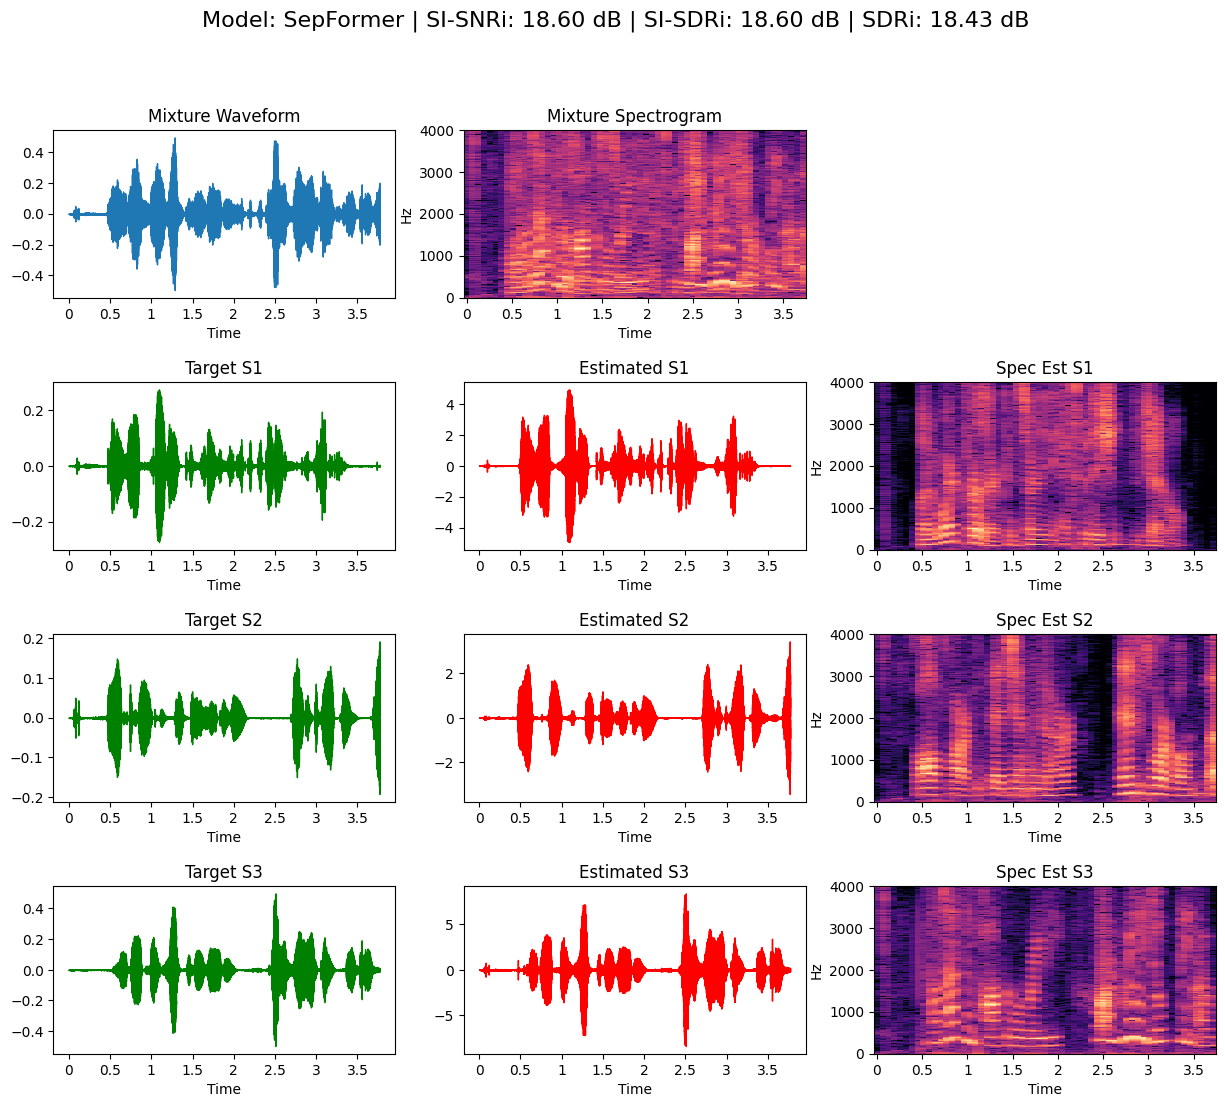

Listen to separated sources:
Source 1:


Source 2:


Source 3:



Evaluating ConvTasNet...
Metrics for ConvTasNet: {'SI-SNRi': 14.62022590637207, 'SI-SDRi': 14.618044376373291, 'SDRi': 14.413092613220215}


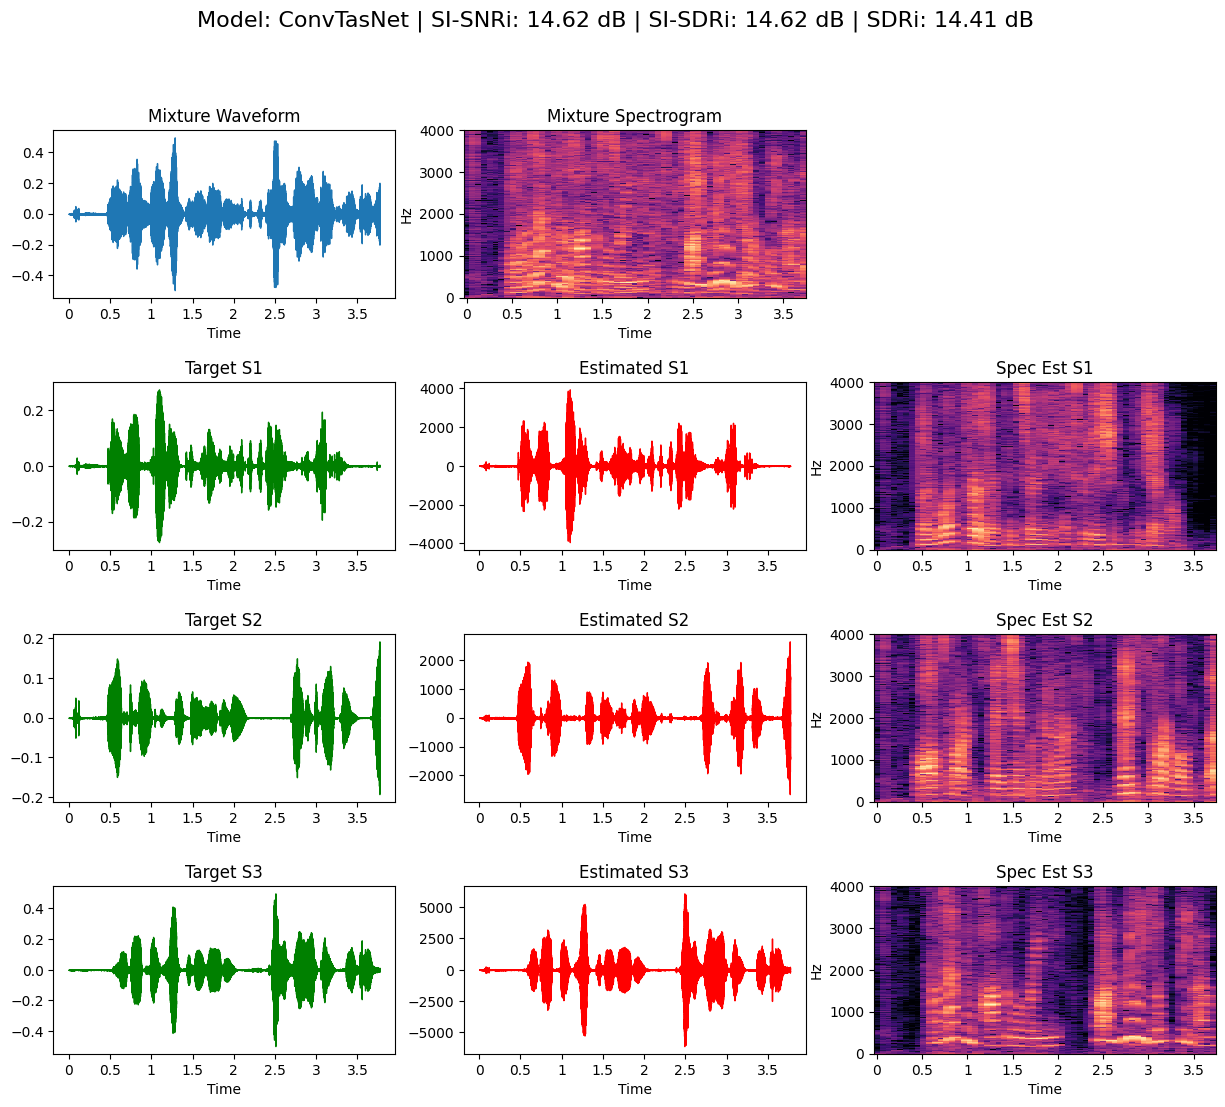

Listen to separated sources:
Source 1:


Source 2:


Source 3:


In [9]:
# In Kaggle, if paths are broken during setup, this will skip nicely
if 'dummy' in df_test.iloc[0]['mixture_path']:
    print("Using dummy audio (please mount your dataset on Kaggle to run real inference)")
    # Create dummy tensors to prevent crashing
    mix = torch.randn(1, 16000)
    s1, s2, s3 = torch.randn(1, 16000), torch.randn(1, 16000), torch.randn(1, 16000)
    sr = 8000
else:
    # Load a sample from the test set
    sample_row = df_test.iloc[0]
    mix, sr = torchaudio.load(sample_row['mixture_path'])
    s1, _ = torchaudio.load(sample_row['source_1_path'])
    s2, _ = torchaudio.load(sample_row['source_2_path'])
    s3, _ = torchaudio.load(sample_row['source_3_path'])

targets_tensor = torch.cat([s1, s2, s3], dim=0) # Shape: (3, samples)
mix_np = mix[0].numpy()

print("Mixture Audio:")
display(Audio(mix_np, rate=sr))

all_results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}\nEvaluating {model_name}...\n{'='*60}")
    
    mix_tensor = mix.to(device)
    if mix_tensor.dim() == 1:
        mix_tensor = mix_tensor.unsqueeze(0)
        
    with torch.no_grad():
        if model_name == 'SepFormer':
            est_sources = model.separate_batch(mix_tensor)
            est_sources = est_sources[0].transpose(0, 1) # to (channels, time)
        else:
            est_sources = model(mix_tensor)
            est_sources = est_sources[0] # to (channels, time)
            
        # MultiDecoderDPRNN might return a list or dict depending on the exact Asteroid implementation,
        # but usually `model(mix)` returns the tensor directly for the predicted speaker count.
    
    metrics, perm = compute_all_metrics(targets_tensor, est_sources, mix_tensor[0])
    all_results[model_name] = metrics
    
    print(f"Metrics for {model_name}: {metrics}")
    
    # Align estimates and convert to numpy for plotting
    aligned_estimates_np = est_sources[perm].cpu().numpy()
    targets_np = targets_tensor.cpu().numpy()
    
    visualize_separation(mix_np, targets_np, aligned_estimates_np, model_name, metrics, sr=sr)
    
    print("Listen to separated sources:")
    for i in range(3):
        print(f"Source {i+1}:")
        display(Audio(aligned_estimates_np[i], rate=sr))

## 7. Summary of Results (SI-SNRi, SI-SDRi, SDRi)
Visualizing the improvement metrics across all 5 architectures.

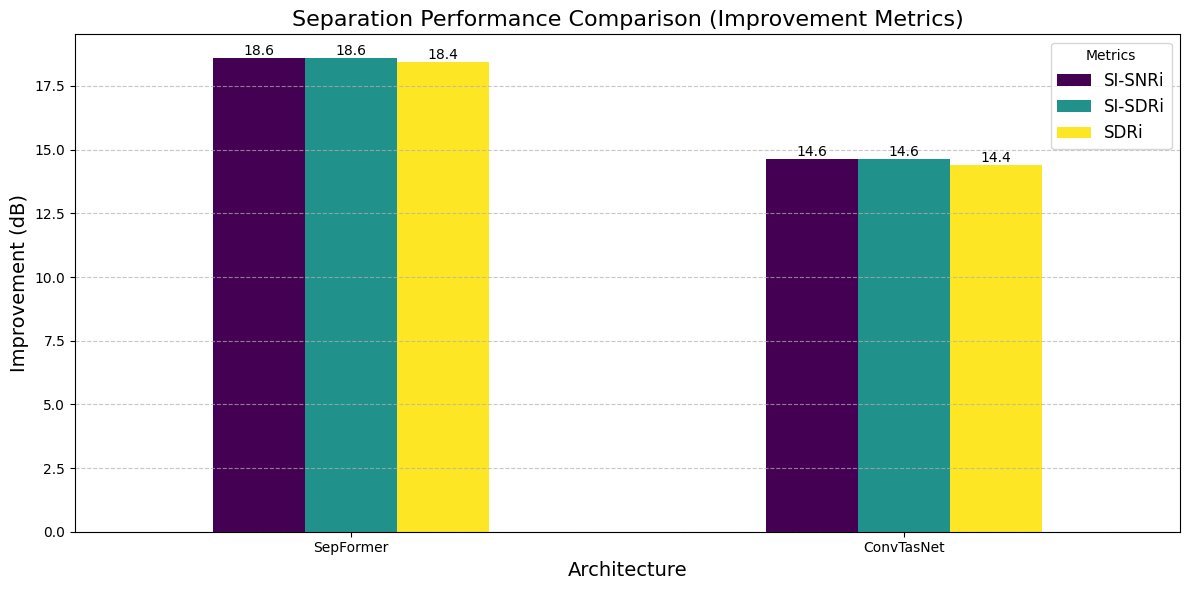

In [10]:
import pandas as pd

df_results = pd.DataFrame(all_results).T

# Plotting the grouped bar chart
ax = df_results.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Separation Performance Comparison (Improvement Metrics)', fontsize=16)
plt.ylabel('Improvement (dB)', fontsize=14)
plt.xlabel('Architecture', fontsize=14)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}", (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)

plt.legend(title="Metrics", fontsize=12)
plt.tight_layout()
plt.show()